# Part 4 - Spatial Modelling

Finally, we will briefly show how Catalyst can create and simulate spatial models. We will consider the one case of spatial modelling that is well supported: modelling on discrete-spaced regular and irregular lattices. These discrete spaces can either be because the simulation is really carried out on a discrete space (i.e. simulating an SIR model with several cities which see movement between themselves) or because a a continuous space have been manually discretised.

First, we create a `DiscreteSpaceReactionSystem`. This couples:
1. A non-spatial `ReactionSystem` (declared e.g. via `@reaction_network`).
2. A vector of spatial reactions (describing how species can move inbetween different compartments).
3. A discrete space on which the simulation is carried out.

Here we extend a brusselator model to a 20x20 grid. The only spatial reaction is linear diffusion of `X` ate rate `D`.

In [9]:
using Catalyst
brusselator = @reaction_network begin
    A, 0 --> X
    1, 2X + Y --> 3X
    B, X --> Y
    1, X --> 0
end
tr = @transport_reaction D X
lattice = CartesianGrid((20, 20))
spatial_brusselator = DiscreteSpaceReactionSystem(brusselator, [tr], lattice)


Model ##ReactionSystem#303:
Unknowns (2): see unknowns(##ReactionSystem#303)
  X(t)
  Y(t)
Parameters (3): see parameters(##ReactionSystem#303)
  A
  B
  D

Next we can simulate the mode using standard syntax. Here, each species initial condition or parameter value can either be
1. A single value (in which case this value is used across space).
2. A datastructure of the same size as the discrete space, where each value correspond to the component's value at that compartment.

Here we will use random initial condition values for `X` and uniform values for `Y`, `A`, and `B`. Using these values, we create and simulate an `ODEProblem` using normal syntax.

In [13]:
u0 = [:X => 10 .* rand(20, 20), :Y => 5.0]
ps = [:A => 1.0, :B => 4.0, :D => 0.2]
spat_prob = ODEProblem(spatial_brusselator, u0, (0.0, 50.0), ps)
spat_sol = solve(spat_prob);

For plotting spatial simulations, Catalyst uses the Makie.jl package. Here, we plot the simulation at a specific time point for the variable `X`:

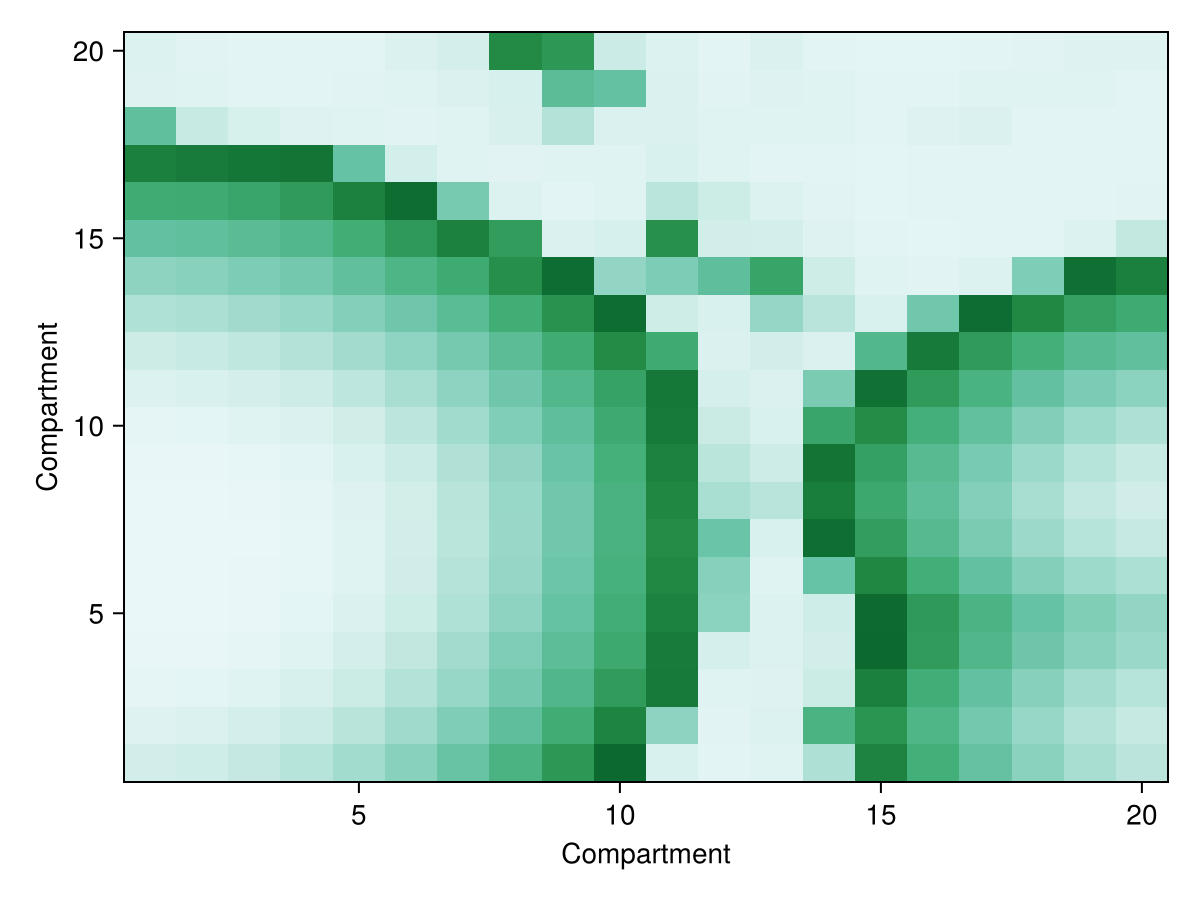

In [18]:
dspace_plot(spat_sol, :X, spatial_brusselator; t = 16.0)

Alternatively, we can create an animation of the simulation: 

In [ ]:
dspace_animation(spat_sol, :X, dsrs, "dspace_simulation_2d.mp4") # Animation saved to "dspace_simulation_2d.mp4" and must be checked manually.

#### Stochastic spatial simulations 
For non-spatial models Catlayst supports three modes of simulation: ODE, SDE, and Jump simulations. For spatial models, only the ODE and Jump approaches are supported. Again, jump simulations can be carried out using a similar syntax (but creating a `JumpProblem` instead, and we also ensures that we have integer-initial condition values for `X`).

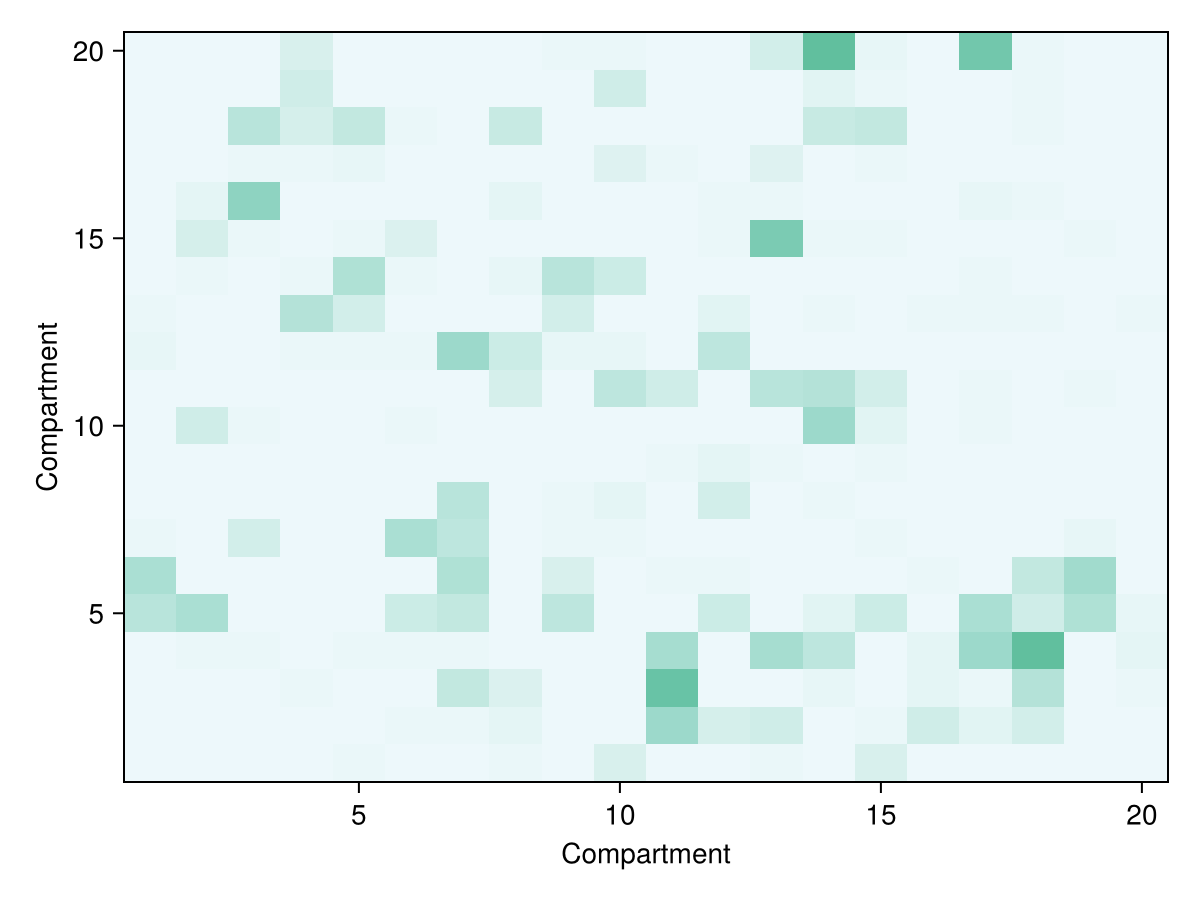

In [30]:
u0 = [:X => rand(1:10, 20, 20), :Y => 5]
ps = [:A => 3.0, :B => 12.0, :D => 0.1]
spat_prob = JumpProblem(spatial_brusselator, u0, (0.0, 50.0), ps)
spat_sol = solve(spat_prob)
dspace_plot(spat_sol, :X, spatial_brusselator; t = 18.0)

In [32]:
dspace_animation(spat_sol, :X, dsrs, "dspace_jump_simulation_2d.mp4")

#### Non-cartesian spaces 
In addition to a regular Cartesian grid, Catalyst supports two additional types of spaces:
1. A masked space. This is a regular Cartesian grid where some compartments have been "removed".
2. Unstructured spaces. These are graphs with arbitrarily defined connections between different compartments.

Catalyst also supports simulations in 1d, 2d, and 3d, as well as different plotting/animation options for the different approaches.

Below we create a masked grid that we simulate the brusselator on.

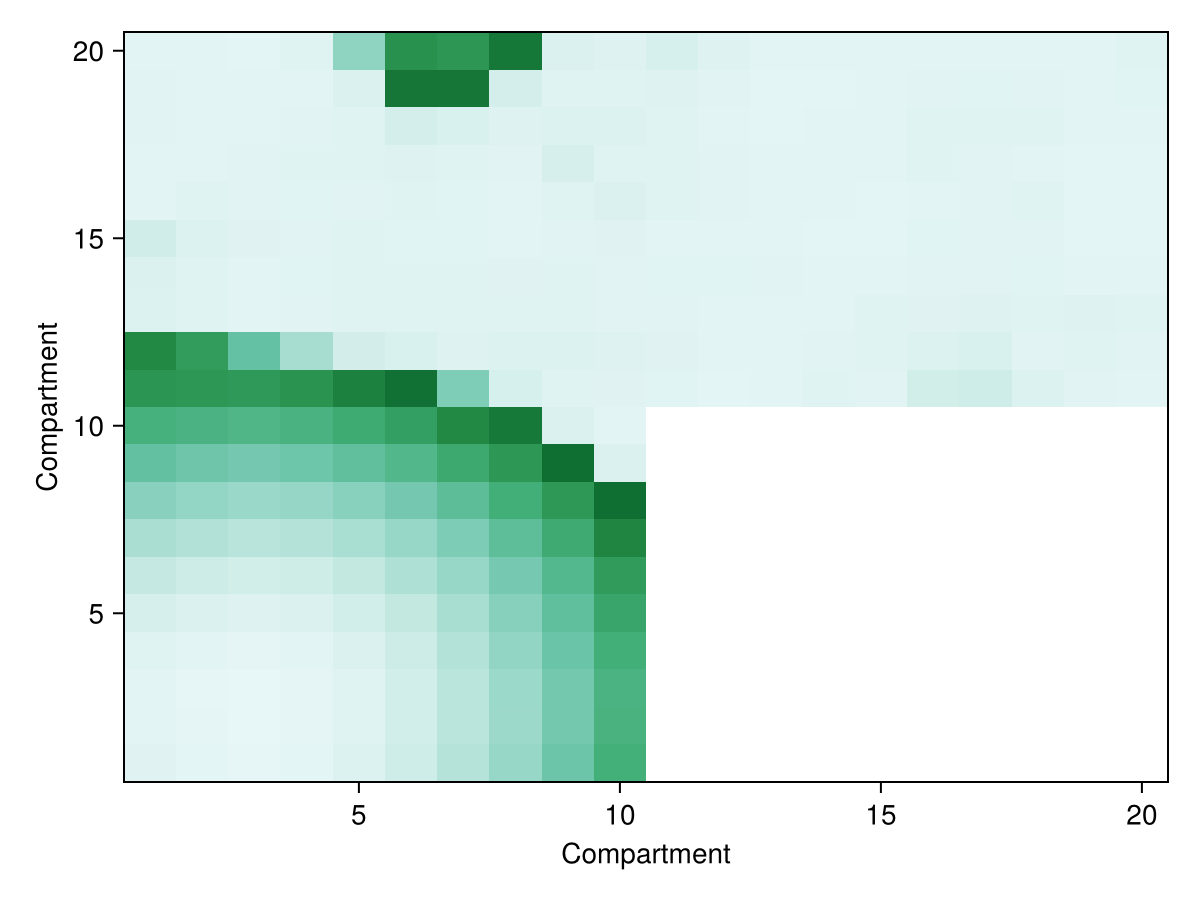

In [41]:
using Catalyst
brusselator = @reaction_network begin
    A, 0 --> X
    1, 2X + Y --> 3X
    B, X --> Y
    1, X --> 0
end
tr = @transport_reaction D X
masked_lattice = [
    fill(true, 10, 10) fill(true, 10, 10);
    fill(false, 10, 10) fill(true, 10, 10)
] # The masked grid is an Boolean array marking which compartments are and are not part of the grid.
masked_brusselator = DiscreteSpaceReactionSystem(brusselator, [tr], masked_lattice)

u0 = [:X => 10 .* rand(20, 20), :Y => 5.0]
ps = [:A => 1.0, :B => 4.0, :D => 0.2]
spat_prob = ODEProblem(masked_brusselator, u0, (0.0, 50.0), ps)
spat_sol = solve(spat_prob);

dspace_plot(spat_sol, :X, masked_brusselator; t = 16.0)

Here, and in the simulation created below, we can see how the bottom corner of the grid is cut out.

In [43]:
dspace_animation(spat_sol, :X, masked_brusselator, "dspace_masked_simulation_2d.mp4")